# Warm-Up: Python Preliminaries

Before we dive into game theory, let's quickly review how to navigate 2D lists (matrices) in Python.

In this assignment, a payoff matrix can be simply used as a list or numpy arrays. You can use either lists or numpy arrays, however I'll be sticking with lists.
You don't need to know advanced programming to solve these games; you just need to understand how to pinpoint a specific cell and how to loop through them automatically.

Run the cell below to see how it works!

In [12]:
#  1. DEFINING A MATRIX
# Think of this as 2 rows and 3 columns
example_matrix = [
    [10, 20, 30], # Row 0
    [40, 50, 60]  # Row 1
]

#  2. ACCESSING A SPECIFIC CELL
# Syntax: matrix[row_index][column_index]


# Let's grab the value in Row 1, Column 2 (which should be 60)
specific_value = example_matrix[1][2]
print(f"1. The value at Row 1, Col 2 is: {specific_value}\n")


#  3. THE NESTED LOOP
# To check every single payoff in a game, we put a loop inside another loop.
# The outer loop goes row by row. The inner loop goes column by column.

num_rows = len(example_matrix)    # This is 2
num_cols = len(example_matrix[0]) # This is 3

print("2. Iterating through all cells:")
for i in range(num_rows):         # i represents our current row
    for j in range(num_cols):     # j represents our current column

        current_cell = example_matrix[i][j]
        print(f"   Cell ({i}, {j}) contains {current_cell}")

# Tip for the assignment: You will use 'i' to represent Player 1's action
# and 'j' to represent Player 2's action!

1. The value at Row 1, Col 2 is: 60

2. Iterating through all cells:
   Cell (0, 0) contains 10
   Cell (0, 1) contains 20
   Cell (0, 2) contains 30
   Cell (1, 0) contains 40
   Cell (1, 1) contains 50
   Cell (1, 2) contains 60


# Work with Numpy Arrays

In [13]:
import numpy as np

#  1. DEFINING A MATRIX
# We wrap standard Python lists inside np.array()
example_matrix = np.array([
    [10, 20, 30], # Row 0
    [40, 50, 60], # Row 1
    [70, 80, 90]  # Row 2
])
print("Our Matrix:\n", example_matrix, "\n")

# 2. ACCESSING A SPECIFIC CELL
# Syntax: matrix[row_index, column_index]


specific_value = example_matrix[1, 2]
print(f"1. The value at Row 1, Col 2 is: {specific_value}\n")


#  3. SLICING (The NumPy Superpower)
# The colon ':' means "give me everything in this dimension".

# Grab an entire Row (e.g., Player 1's payoffs if they play action 0)
row_zero = example_matrix[0, :]
print(f"2. All of Row 0: {row_zero}")

# Grab an entire Column (e.g., Player 1's payoffs if Player 2 plays action 2)
col_two = example_matrix[:, 2]
print(f"3. All of Column 2: {col_two}\n")


# Tip for the assignment: If you need to find the maximum payoff in a specific
# column to check for a best response, you can just do: max(example_matrix[:, j])

Our Matrix:
 [[10 20 30]
 [40 50 60]
 [70 80 90]] 

1. The value at Row 1, Col 2 is: 60

2. All of Row 0: [10 20 30]
3. All of Column 2: [30 60 90]



## Lists to Numpy Arrays

```

```



In game theory and data science, you will often work with different types of data structures. Sometimes a matrix is provided as a standard Python list of lists: `[[1, 2], [3, 4]]`. Other times, it is a mathematical NumPy array: `np.array([[1, 2], [3, 4]])`.

The problem? Standard Python lists do not support the magical NumPy slicing (`matrix[:, 1]`) we just learned.

**The Solution: `np.asarray()`**
Professional developers use a technique called "input sanitization" to ensure the data is in the format they need before doing math on it. By wrapping any input matrix in `np.asarray()`, Python will automatically convert standard lists into NumPy arrays.

In [14]:

def extract_column_safely(matrix, col_index):
    """
    This function safely extracts a column, regardless of whether
    the user passes a standard list or a NumPy array.
    """
    # 1. Sanitize the input
    safe_matrix = np.asarray(matrix)

    # 2. Now you can safely use NumPy slicing!
    column = safe_matrix[:, col_index]

    return column

# Let's test it with a standard Python list (NOT a NumPy array)
standard_list_matrix = [
    [100, 200],
    [300, 400]
]

# Even though we passed a standard list, it won't crash!
extracted = extract_column_safely(standard_list_matrix, 1)
print(f"Successfully extracted column 1: {extracted}")



Successfully extracted column 1: [200 400]


# Building a Game Solver: General-Sum Rock, Paper, Scissors

Welcome to the next phase of your game theory assignment. We are exploring a modified, **General-Sum** version of Rock, Paper, Scissors.

Unlike classic parlor games, real-world strategic interactions are rarely strictly competitive (zero-sum).
**The  Rules (Asymmetric Payoffs):**
* **Winning with Rock** against Scissors gives a high payoff (+3), but losing with Rock against Paper is devastating (-2).
* **Draws** are no longer neutral; clashing results in mutual damage (-1, -1).
* Player 1 and Player 2 have distinct payoff matrices. $B \neq -A$.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# TODO: Define the General-Sum Payoff Matrices for Player 1 (A) and Player 2 (B)
# Notice that these do not sum to zero!

# Rows: P1 plays Rock, Paper, Scissors
# Cols: P2 plays Rock, Paper, Scissors
A_gen = [
    [-1, -2,  3], # Rock
    [ 1, -1, -1], # Paper
    [-2,  2, -1]  # Scissors
]

B_gen = [
    [-1,  2, -2],
    [-2, -1,  1],
    [ 3, -1, -1]
]

print("Player 1 Payoff Matrix (A):")
print(np.array(A_gen))
print("\nPlayer 2 Payoff Matrix (B):")
print(np.array(B_gen))

Player 1 Payoff Matrix (A):
[[-1 -2  3]
 [ 1 -1 -1]
 [-2  2 -1]]

Player 2 Payoff Matrix (B):
[[-1  2 -2]
 [-2 -1  1]
 [ 3 -1 -1]]


## Part 2: Checking for Pure Strategy Nash Equilibria
Because this is not a zero-sum game, we cannot look for saddle points. We must strictly apply the definition of a Nash Equilibrium: an action profile $(i, j)$ where **neither** player can unilaterally deviate to increase their own payoff.

**Your Task:** Write a function that tests all 9 possible states.
* Does $A_{i,j}$ represent Player 1's best response to column $j$?
* Does $B_{i,j}$ represent Player 2's best response to row $i$?

In [16]:
def find_pure_nash_general(A, B):
    equilibria = []
    rows = len(A)
    cols = len(A[0])

    # TODO: Loop through all combinations of row i and col j.
    # TODO: Verify P1 cannot improve by changing rows (compare A[i][j] to other rows in col j).
    # TODO: Verify P2 cannot improve by changing cols (compare B[i][j] to other cols in row i).
    for i in range(rows):
      for j in range(cols):
         p1_best = A[i][j] == max(A[r][j] for r in range(rows))
         p2_best = B[i][j] == max(B[i][r] for r in range(cols))

         if p1_best and p2_best:
                equilibria.append((i, j))


    return equilibria

# Run the check
pne_results = find_pure_nash_general(A_gen, B_gen)
print(f"Pure Nash Equilibria found at indices: {pne_results}")

Pure Nash Equilibria found at indices: []


## Part 3: Expected Payoffs in a General-Sum World
To find a mixed equilibrium, we look for the probability distribution that makes the *opponent* indifferent between their choices.

Let's define Player 1's mixed strategy: $(p_{\text{rock}}, p_{\text{paper}}, p_{\text{scissors}})$.

**Your Task:** Write a function that calculates **Player 2's** expected payoff for each of their pure actions, given Player 1's mixed strategy.
*Note: Because the game is general-sum, you MUST use Matrix B for Player 2's expected utility, not Matrix A.*

In [17]:
def expected_payoff_p2(p_rock, p_paper, B, p2_action_index):
    """
    Calculates Player 2's expected payoff when playing a specific pure action
    (0=Rock, 1=Paper, 2=Scissors), against P1's mixed strategy.
    """
    p_scissors = 1.0 - p_rock - p_paper

    # TODO: Implement the expected payoff formula for Player 2 using Matrix B!
    # Hint: P2's payoff for playing Rock is driven by the first COLUMN of B.
    column= extract_column_safely(B,p2_action_index)
    value= p_rock*column[0]+p_paper*column[1]+p_scissors*column[2]

    return value

## Part 4: Plotting the Indifference Surfaces
We will plot Player 2's expected payoffs based on Player 1's probability distribution. The intersection of these surfaces represents the point where Player 2 is completely indifferent between playing Rock, Paper, or Scissors—a necessary condition for a Mixed Nash Equilibrium.

**Your Task:** Generate the `Z` values for Player 2's payoffs using your function from Part 3.

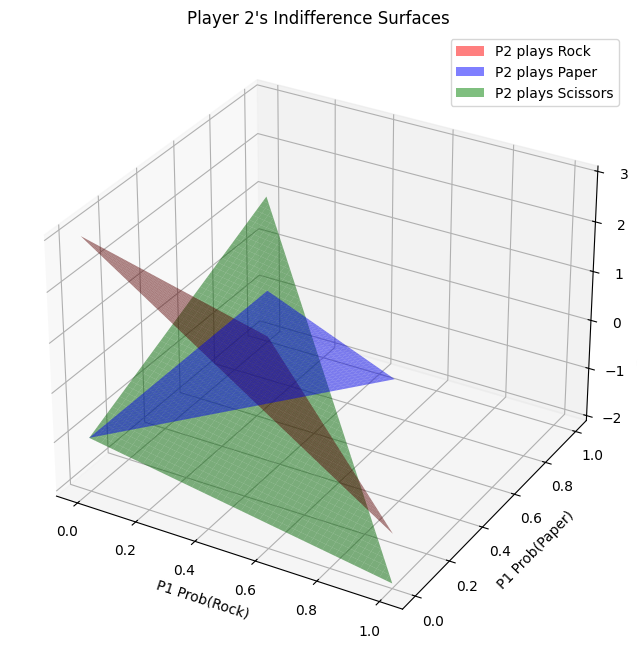

In [18]:
# 1. Generate Probability Grid for Player 1
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
resolution = 50
p_vals = np.linspace(0, 1, resolution)
P_ROCK, P_PAPER = np.meshgrid(p_vals, p_vals)

valid_mask = (P_ROCK + P_PAPER) <= 1.0
P_ROCK = np.where(valid_mask, P_ROCK, np.nan)
P_PAPER = np.where(valid_mask, P_PAPER, np.nan)

# 2. Calculate P2's Expected Payoffs (Z-axis)
# TODO: Calculate Z_rock, Z_paper, and Z_scissors using expected_payoff_p2()
Z_rock= expected_payoff_p2(P_ROCK,P_PAPER,B_gen,0)
Z_paper= expected_payoff_p2(P_ROCK,P_PAPER,B_gen,1)
Z_scissors= expected_payoff_p2(P_ROCK,P_PAPER,B_gen,2)

# Example placeholders:
#Z_rock = np.zeros_like(P_ROCK)
#Z_paper = np.zeros_like(P_ROCK)
#Z_scissors = np.zeros_like(P_ROCK)


# 3. Plotting the Indifference Surfaces
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

surf1 = ax.plot_surface(P_ROCK, P_PAPER, Z_rock, alpha=0.5, color='red')
surf2 = ax.plot_surface(P_ROCK, P_PAPER, Z_paper, alpha=0.5, color='blue')
surf3 = ax.plot_surface(P_ROCK, P_PAPER, Z_scissors, alpha=0.5, color='green')

ax.set_xlabel('P1 Prob(Rock)')
ax.set_ylabel('P1 Prob(Paper)')
ax.set_zlabel('Expected Payoff for P2')
ax.set_title("Player 2's Indifference Surfaces")

proxy1 = plt.Rectangle((0, 0), 1, 1, fc="red", alpha=0.5)
proxy2 = plt.Rectangle((0, 0), 1, 1, fc="blue", alpha=0.5)
proxy3 = plt.Rectangle((0, 0), 1, 1, fc="green", alpha=0.5)
ax.legend([proxy1, proxy2, proxy3], ['P2 plays Rock', 'P2 plays Paper', 'P2 plays Scissors'])

plt.show()

## Part 5: Expected Utility and Compound Lotteries

In the real world, decisions rarely lead directly to a final outcome. Often, a decision leads to a *probabilistic state*, which then leads to a *probabilistic outcome*. This is known as a **Compound Lottery**.

**The Scenario: Quantitative Trading Strategy**\
You are evaluating an algorithmic trading strategy. The outcome depends on two stages:
1. **The Market State (Stage 1):** The market can either enter a *High Volatility* state or a *Low Volatility* state.
2. **The Execution Outcome (Stage 2):** Depending on the market state, the algorithm will execute trades resulting in a *Massive Profit*, a *Small Profit*, or a *Loss*.

According to the **Reduction of Compound Lotteries Axiom**, any compound lottery can be reduced to a "simple lottery" over the final outcomes by multiplying the probabilities.
Specifically for this section, you can use **numpy arrays or lists**

In [19]:


# Stage 1: Probabilities of Market States [High Volatility, Low Volatility]
P_market_state = np.array([0.60, 0.40])

# Stage 2: Probabilities of Outcomes [Massive Profit, Small Profit, Loss]
# GIVEN the market state.
# Row 0: If High Volatility
# Row 1: If Low Volatility
P_outcomes_given_state = np.array([
    [0.30, 0.20, 0.50], # High Vol risk: 30% massive profit, 50% loss
    [0.05, 0.80, 0.15]  # Low Vol risk: 80% small profit, 15% loss
])

# The Utility (Value) of each final outcome
# Massive Profit = 100, Small Profit = 10, Loss = -40
Utilities = np.array([100, 10, -40])

print("Stage 1 Probabilities:\n", P_market_state)
print("\nStage 2 Conditional Probabilities:\n", P_outcomes_given_state)

Stage 1 Probabilities:
 [0.6 0.4]

Stage 2 Conditional Probabilities:
 [[0.3  0.2  0.5 ]
 [0.05 0.8  0.15]]


### Task 5.2: Calculating Expected Utility
Now that you have a simple lottery mapping directly to final outcomes, you can calculate the overall Expected Utility of deploying this trading algorithm.

Expected Utility is the sum of the probability of each outcome multiplied by its utility:
$$E[U] = \sum_{i} p_i \cdot U_i$$

**Your Task:** Calculate the expected utility. Is the strategy worth running?

In [21]:
def calculate_expected_utility(p_final, utilities):
    """
    Calculates the expected utility of a simple lottery.
    """
    # TODO: Calculate the expected utility.
    # Hint: You can use another dot product, or np.sum() with element-wise multiplication!

    expected_utility = np.dot(p_final, utilities) # Replace this!

    return expected_utility
simple_lottery = np.dot(P_market_state, P_outcomes_given_state)
eu = calculate_expected_utility(simple_lottery, Utilities)

print(f"The Expected Utility of the strategy is: {eu}")

The Expected Utility of the strategy is: 10.0
